# CommonLit Readability 글 난이도 예측 (회귀)

지문(excerpt)의 읽기 난이도 target 예측. 낮을수록 어려움. 평가지표 RMSE.

1. EDA
2. Baseline: TF-IDF + Ridge
3. 가독성 피처 실험
4. DistilBERT 회귀
5. 분석 (RMSE, 예측-실제 산점도, 잔차, 과대/과소예측)
6. 제출

test는 7행뿐. 코드대회라 실제 채점셋은 숨겨져 있음.

In [1]:
import os, re, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 140)

SEED = 42
def seed_everything(seed=SEED):
 random.seed(seed); np.random.seed(seed)
 try:
 import torch
 torch.manual_seed(seed)
 if torch.backends.mps.is_available(): torch.mps.manual_seed(seed)
 except Exception: pass
seed_everything()

DATA_DIR = "data_commonlit"
FIG_DIR = "figures_commonlit"
os.makedirs(FIG_DIR, exist_ok=True)

def rmse(y_true, y_pred): # 평가지표, 함수로
 return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))
print("setup done.")

setup done.


## 0. 데이터 로드 & EDA

In [2]:
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
print("train:", train.shape, "| test:", test.shape)
print("columns:", list(train.columns))
print("\n결측치:\n", train.isna().sum())
# url/license는 70% 결측, 출처 메타라 안 씀. 쓸 건 excerpt랑 target
train.head(2)

train: (2834, 6) | test: (7, 4)
columns: ['id', 'url_legal', 'license', 'excerpt', 'target', 'standard_error']

결측치:
 id                   0
url_legal         2004
license           2004
excerpt              0
target               0
standard_error       0
dtype: int64


,id,url_legal,license,excerpt,target,standard_error
0,c12129c31,NaN,NaN,"When the young people returned to the ballroom, it presented a decidedly changed appearance. Instead of an interior scene, it was a wint...",-0.340259,0.464009
1,85aa80a4c,NaN,NaN,"All through dinner time, Mrs. Fayre was somewhat silent, her eyes resting on Dolly with a wistful, uncertain expression. She wanted to g...",-0.315372,0.480805


count    2834.000
mean       -0.959
std         1.034
min        -3.676
25%        -1.690
50%        -0.912
75%        -0.203
max         1.711
Name: target, dtype: float64


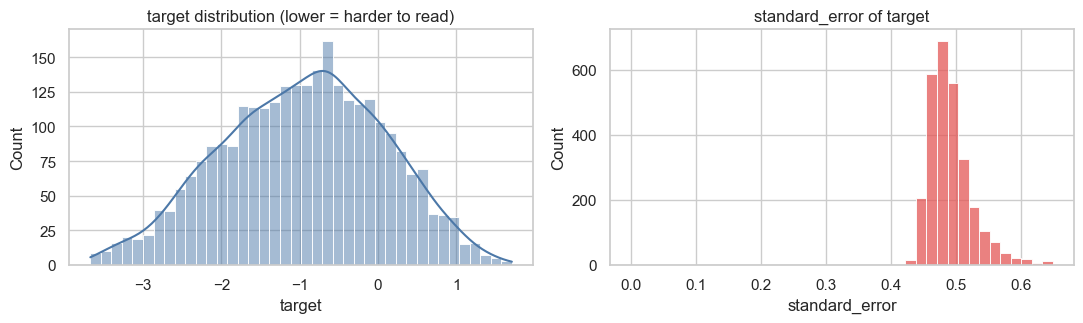

In [3]:
# target 분포. 회귀라 모양이 중요(치우침/꼬리)
print(train["target"].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
sns.histplot(train["target"], bins=40, kde=True, ax=axes[0], color="#4C78A8")
axes[0].set_title("target distribution (lower = harder to read)")
sns.histplot(train["standard_error"], bins=40, ax=axes[1], color="#E45756")
axes[1].set_title("standard_error of target")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/target_dist.png", dpi=120); plt.show()
# target 종모양(평균 -0.96). 치우침 없어 변환 안 함. standard_error는 라벨 불확실성

길이 통계:
       n_chars  n_words
min     669.0    135.0
mean    972.0    173.0
max    1341.0    205.0

target과 상관계수:
n_chars   -0.363
n_words   -0.124
target     1.000
Name: target, dtype: float64


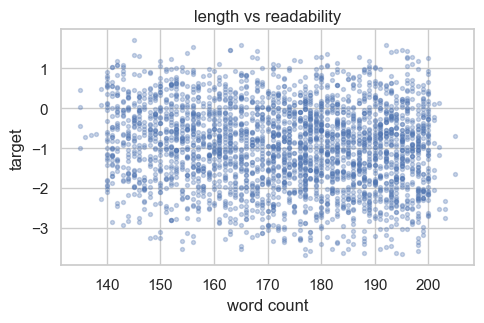

In [4]:
# 길이랑 난이도 상관 있나
train["n_chars"] = train["excerpt"].str.len()
train["n_words"] = train["excerpt"].str.split().apply(len)
print("길이 통계:\n", train[["n_chars","n_words"]].describe().loc[["min","mean","max"]].round(0))
print("\ntarget과 상관계수:")
print(train[["n_chars","n_words","target"]].corr()["target"].round(3))

fig, ax = plt.subplots(figsize=(5,3.4))
ax.scatter(train["n_words"], train["target"], s=8, alpha=0.3)
ax.set_xlabel("word count"); ax.set_ylabel("target"); ax.set_title("length vs readability")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/len_vs_target.png", dpi=120); plt.show()
# 길이 거의 일정(일부러 자른 듯). 난이도랑 상관 거의 없음 -> 어휘/구조를 봐야 함

### EDA 정리

- 쓸 컬럼은 excerpt 하나. url/license는 제외
- target은 종모양 → 변환 없이 회귀
- 길이로는 난이도 안 갈림 → 어휘/구조가 핵심

## 1. Baseline: TF-IDF + Ridge

In [5]:
# 줄바꿈/특수문자만 정리. 단어 정보는 최대한 보존
def clean_text(s):
 s = str(s).lower()
 s = re.sub(r"\s+", " ", s) # 공백 정리
 s = re.sub(r"[^a-z0-9\s\.\,\!\?\;\:']", " ", s) # 문장부호 일부 남김(난이도 신호)
 s = re.sub(r"\s+", " ", s).strip()
 return s

train["clean"] = train["excerpt"].map(clean_text)
test["clean"] = test["excerpt"].map(clean_text)

from sklearn.model_selection import train_test_split
tr_idx, va_idx = train_test_split(train.index, test_size=0.15, random_state=SEED)
y_tr = train.loc[tr_idx, "target"].values
y_va = train.loc[va_idx, "target"].values
print(f"train: {len(tr_idx)} / val: {len(va_idx)}")

train: 2408 / val: 426


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold

def make_tfidf():
 # min_df=3, 희귀 토큰은 과적합
 return TfidfVectorizer(ngram_range=(1,2), min_df=3, sublinear_tf=True)

X_text = train["clean"]
kf = KFold(5, shuffle=True, random_state=SEED)

# alpha 훑기. 텍스트 회귀는 약한 정규화가 보통 나음
print("=== Ridge alpha 튜닝 (5-fold CV RMSE) ===")
best_alpha, best_cv = None, 1e9
for alpha in [0.3, 1.0, 2.0, 5.0]:
 pipe = Pipeline([("tfidf", make_tfidf()), ("ridge", Ridge(alpha=alpha))])
 neg = cross_val_score(pipe, X_text, train["target"], cv=kf, scoring="neg_mean_squared_error")
 cv_rmse = np.sqrt(-neg).mean()
 print(f" alpha={alpha:4.1f} -> CV RMSE = {cv_rmse:.4f}")
 if cv_rmse < best_cv: best_cv, best_alpha = cv_rmse, alpha
print("-> best alpha:", best_alpha)

# 고정 val 점수(비교용)
base_pipe = Pipeline([("tfidf", make_tfidf()), ("ridge", Ridge(alpha=best_alpha))])
base_pipe.fit(X_text.loc[tr_idx], y_tr)
pred_base_val = base_pipe.predict(X_text.loc[va_idx])
print(f"\nbaseline val RMSE = {rmse(y_va, pred_base_val):.4f}")
print(f"(참고) 평균만 찍는 naive RMSE = {rmse(y_va, np.full_like(y_va, y_tr.mean())):.4f}")

=== Ridge alpha 튜닝 (5-fold CV RMSE) ===


  alpha= 0.3 -> CV RMSE = 0.7152


  alpha= 1.0 -> CV RMSE = 0.7214


  alpha= 2.0 -> CV RMSE = 0.7411


  alpha= 5.0 -> CV RMSE = 0.7918
-> best alpha: 0.3



baseline val RMSE = 0.6984
(참고) 평균만 찍는 naive RMSE = 1.0156


### Baseline 결과

- TF-IDF + Ridge로 RMSE 0.70. naive(평균예측 1.03)보다 좋음
- 선형모델은 어순/문맥을 못 봐서 한계
- 다음: 가독성 피처, 그다음 DistilBERT

## 1.5 가독성 피처 실험

가설: 문장 길이, 음절 수 같은 가독성 지표를 더하면 도움이 될 것이다. baseline에 얹어서 확인.

In [7]:
# textstat 없이 직접. 가독성 지표 손으로 뽑음
def count_syllables(word):
 # 음절 근사: 모음 그룹 수 + 끝 묵음 e 보정
 word = word.lower()
 groups = re.findall(r"[aeiouy]+", word)
 n = len(groups)
 if word.endswith("e") and n > 1: n -= 1
 return max(n, 1) if re.search(r"[a-z]", word) else 0

def readability_features(text):
 sents = [s for s in re.split(r"[.!?]+", text) if s.strip()]
 words = re.findall(r"[A-Za-z']+", text)
 n_sent = max(len(sents), 1); n_word = max(len(words), 1)
 syl = sum(count_syllables(w) for w in words)
 long_words = sum(1 for w in words if len(w) > 6)
 uniq = len(set(w.lower() for w in words))
 flesch = 206.835 - 1.015 * (n_word / n_sent) - 84.6 * (syl / n_word) # 높을수록 쉬움
 return {
 "r_avg_sent_len": n_word / n_sent, # 문장당 단어수
 "r_avg_word_len": np.mean([len(w) for w in words]),
 "r_avg_syllable": syl / n_word, # 단어당 음절
 "r_pct_long": long_words / n_word, # 긴 단어 비율
 "r_ttr": uniq / n_word, # type-token ratio(어휘 다양성)
 "r_flesch": flesch,
 }

rf = pd.DataFrame([readability_features(t) for t in train["excerpt"]], index=train.index)
print(rf.describe().round(2).loc[["mean","min","max"]])
print("\n각 가독성 피처와 target 상관:")
print(rf.join(train["target"]).corr()["target"].round(3).sort_values())
# Flesch는 +상관, 문장길이/음절은 -상관. 방향 다 상식대로

      r_avg_sent_len  r_avg_word_len  r_avg_syllable  r_pct_long  r_ttr  \
mean           20.88            4.43            1.45        0.18   0.61   
min             4.51            3.14            1.02        0.00   0.20   
max           102.00            6.88            2.45        0.56   0.77   

      r_flesch  
mean     63.35  
min     -31.48  
max     109.55  

각 가독성 피처와 target 상관:
r_pct_long       -0.474
r_avg_syllable   -0.461
r_avg_word_len   -0.421
r_avg_sent_len   -0.319
r_ttr            -0.184
r_flesch          0.540
target            1.000
Name: target, dtype: float64


In [8]:
# TF-IDF만 vs +가독성, 같은 val에서 비교
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler

tfidf_fitted = make_tfidf().fit(train.loc[tr_idx, "clean"])
scaler = StandardScaler().fit(rf.loc[tr_idx])

def build_X(idx):
 Xt = tfidf_fitted.transform(train.loc[idx, "clean"])
 Xr = csr_matrix(scaler.transform(rf.loc[idx]))
 return hstack([Xt, Xr]).tocsr()

ridge_a = Ridge(alpha=1.0).fit(tfidf_fitted.transform(train.loc[tr_idx, "clean"]), y_tr)
rmse_tfidf = rmse(y_va, ridge_a.predict(tfidf_fitted.transform(train.loc[va_idx, "clean"])))

ridge_b = Ridge(alpha=1.0).fit(build_X(tr_idx), y_tr)
pred_read_val = ridge_b.predict(build_X(va_idx))
rmse_read = rmse(y_va, pred_read_val)

print(f"TF-IDF only : val RMSE = {rmse_tfidf:.4f}")
print(f"TF-IDF + 가독성 피처 : val RMSE = {rmse_read:.4f}")
print(f"개선폭(작을수록 좋음): {rmse_read - rmse_tfidf:+.4f}")

TF-IDF only          : val RMSE = 0.7017
TF-IDF + 가독성 피처 : val RMSE = 0.6928
개선폭(작을수록 좋음): -0.0089


### 가독성 실험 결과

- 가독성 지표들은 target과 상식적인 방향의 상관. 방향은 맞음
- 그래도 RMSE 개선은 작음
- 문맥은 DistilBERT가 할 일

## 2. 개선: DistilBERT 회귀

출력 1개(num_labels=1) + MSE로 점수 회귀. 지문이 길어서 max_length=256.

In [9]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 256 # 토큰 p95=259라 256이면 대부분 커버
BATCH = 16 # 길어서 32->16
EPOCHS = 4 # 데이터 작아 조금 더, val로 과적합 감시
LR = 2e-5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
def encode(texts):
 return tokenizer(list(texts), truncation=True, padding="max_length",
 max_length=MAX_LEN, return_tensors="pt")

enc_tr = encode(train.loc[tr_idx, "excerpt"]) # BERT엔 원문 그대로
enc_va = encode(train.loc[va_idx, "excerpt"])
train_ds = TensorDataset(enc_tr["input_ids"], enc_tr["attention_mask"], torch.tensor(y_tr, dtype=torch.float))
val_ds = TensorDataset(enc_va["input_ids"], enc_va["attention_mask"], torch.tensor(y_va, dtype=torch.float))
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
print("batches/epoch:", len(train_loader))

device: mps


batches/epoch: 151


In [10]:
@torch.no_grad()
def predict_reg(model, loader):
 model.eval(); outs = []
 for batch in loader:
 ids, attn = batch[0].to(device), batch[1].to(device)
 logits = model(input_ids=ids, attention_mask=attn).logits.squeeze(-1)
 outs.append(logits.cpu())
 return torch.cat(outs).numpy()

seed_everything()
# num_labels=1이면 HF가 알아서 회귀(MSE). labels는 float
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * total_steps), total_steps)

best_rmse, best_state = 1e9, None
for epoch in range(1, EPOCHS + 1):
 model.train(); t0 = time.time(); running = 0.0
 for ids, attn, lab in train_loader:
 ids, attn, lab = ids.to(device), attn.to(device), lab.to(device)
 loss = model(input_ids=ids, attention_mask=attn, labels=lab).loss
 loss.backward()
 torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
 optimizer.step(); scheduler.step(); optimizer.zero_grad()
 running += loss.item()
 val_rmse = rmse(y_va, predict_reg(model, val_loader))
 print(f"[epoch {epoch}] train_mse={running/len(train_loader):.4f} | val_RMSE={val_rmse:.4f} | {time.time()-t0:.0f}s")
 if val_rmse < best_rmse: # RMSE 낮은 시점 저장
 best_rmse = val_rmse
 best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

print("\nbest val RMSE:", round(best_rmse, 4))
model.load_state_dict(best_state)
pred_bert_val = predict_reg(model, val_loader)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[epoch 1] train_mse=0.7560 | val_RMSE=0.6220 | 129s


[epoch 2] train_mse=0.2705 | val_RMSE=0.5299 | 123s


[epoch 3] train_mse=0.1758 | val_RMSE=0.5710 | 123s


[epoch 4] train_mse=0.1208 | val_RMSE=0.5439 | 130s

best val RMSE: 0.5299


### DistilBERT 결과

- baseline보다 RMSE 하락
- 데이터 작아 금방 과적합 → best 시점 저장

## 3. 결과 분석: RMSE / 예측-실제 / 잔차 / 과대·과소예측

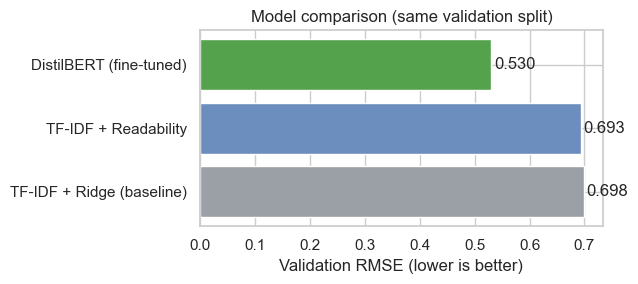

                    model  val_RMSE
TF-IDF + Ridge (baseline)    0.6984
     TF-IDF + Readability    0.6928
  DistilBERT (fine-tuned)    0.5299


In [11]:
summary = pd.DataFrame({
 "model": ["TF-IDF + Ridge (baseline)", "TF-IDF + Readability", "DistilBERT (fine-tuned)"],
 "val_RMSE": [rmse(y_va, pred_base_val), rmse(y_va, pred_read_val), rmse(y_va, pred_bert_val)],
}).sort_values("val_RMSE", ascending=False)

fig, ax = plt.subplots(figsize=(6.5, 3))
bars = ax.barh(summary["model"], summary["val_RMSE"], color=["#9AA0A6", "#6C8EBF", "#54A24B"])
ax.set_xlabel("Validation RMSE (lower is better)")
ax.set_title("Model comparison (same validation split)")
for b, v in zip(bars, summary["val_RMSE"]): ax.text(v+0.005, b.get_y()+b.get_height()/2, f"{v:.3f}", va="center")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/model_compare.png", dpi=120); plt.show()
print(summary.round(4).to_string(index=False))

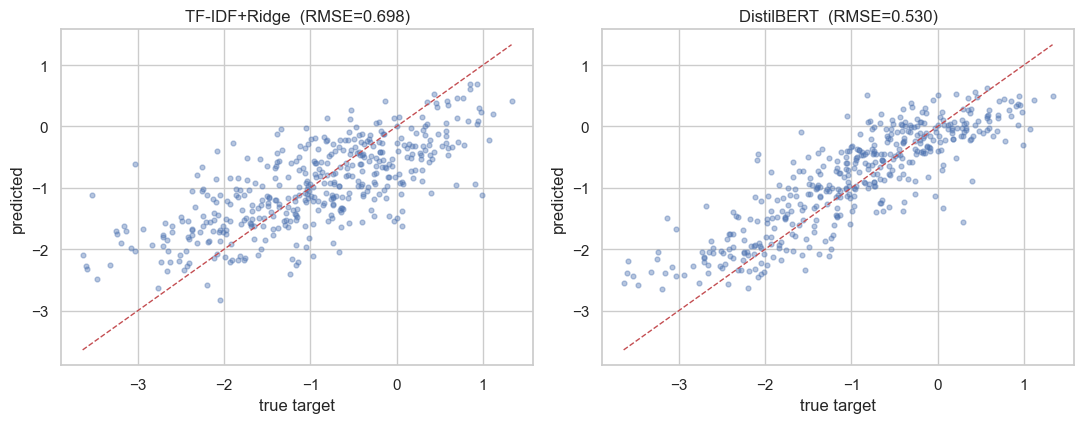

In [12]:
# 예측vs실제 + 잔차, 나란히
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, pred, name in zip(axes, [pred_base_val, pred_bert_val], ["TF-IDF+Ridge", "DistilBERT"]):
 ax.scatter(y_va, pred, s=12, alpha=0.4)
 lim = [min(y_va.min(), pred.min()), max(y_va.max(), pred.max())]
 ax.plot(lim, lim, "r--", lw=1) # 완벽하면 이 선 위에 다 옴
 ax.set_xlabel("true target"); ax.set_ylabel("predicted")
 ax.set_title(f"{name} (RMSE={rmse(y_va, pred):.3f})")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/pred_vs_true.png", dpi=120); plt.show()

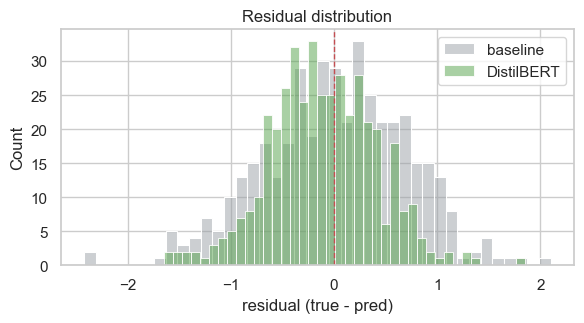

잔차 표준편차  baseline: 0.698 | DistilBERT: 0.518
잔차 평균(편향) baseline: 0.014 | DistilBERT: -0.111


In [13]:
# 잔차 분포. 0 중심 좁을수록 good, 쏠림 있나 확인
resid_base = y_va - pred_base_val
resid_bert = y_va - pred_bert_val
fig, ax = plt.subplots(figsize=(6,3.4))
sns.histplot(resid_base, bins=40, color="#9AA0A6", alpha=0.5, label="baseline", ax=ax)
sns.histplot(resid_bert, bins=40, color="#54A24B", alpha=0.5, label="DistilBERT", ax=ax)
ax.axvline(0, color="r", ls="--", lw=1); ax.set_xlabel("residual (true - pred)"); ax.legend()
ax.set_title("Residual distribution")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/residuals.png", dpi=120); plt.show()
print("잔차 표준편차 baseline:", round(resid_base.std(),3), "| DistilBERT:", round(resid_bert.std(),3))
print("잔차 평균(편향) baseline:", round(resid_base.mean(),3), "| DistilBERT:", round(resid_bert.mean(),3))

In [14]:
# FP/FN 대신 가장 크게 틀린 예측 읽어보기
val_df = train.loc[va_idx, ["excerpt", "target"]].copy()
val_df["pred"] = pred_bert_val
val_df["error"] = val_df["pred"] - val_df["target"] # +면 과대(쉽다고 봄), -면 과소

over = val_df.sort_values("error", ascending=False).head(3) # 과대예측 worst
under = val_df.sort_values("error").head(3) # 과소예측 worst

print("### 과대예측 worst (실제보다 '쉽다'고 잘못 봄):\n")
for _, r in over.iterrows():
 print(f"[true={r.target:+.2f} pred={r.pred:+.2f} err={r.error:+.2f}]")
 print(" ", r.excerpt[:200].replace(chr(10)," "), "...\n")
print("### 과소예측 worst (실제보다 '어렵다'고 잘못 봄):\n")
for _, r in under.iterrows():
 print(f"[true={r.target:+.2f} pred={r.pred:+.2f} err={r.error:+.2f}]")
 print(" ", r.excerpt[:200].replace(chr(10)," "), "...\n")

### 과대예측 worst (실제보다 '쉽다'고 잘못 봄):

[true=-3.14 pred=-1.49 err=+1.65]
   Environmental science is an interdisciplinary academic field that integrates physical, biological and information sciences (including ecology, biology, physics, chemistry, zoology, mineralogy, oceanol ...

[true=-2.08 pred=-0.45 err=+1.63]
   The lad went away with the can to the well, and filled it with water, and then came away home again; but the can being broken, the most part of the water had run out before he got back. So his cake wa ...

[true=-2.10 pred=-0.55 err=+1.55]
   The owner of the island and sheep, A.P. Moore, a few years ago purchased the property from the widow of his deceased brother Henry, for $600,000. Owing to ill health, he has rented it to his brother L ...

### 과소예측 worst (실제보다 '어렵다'고 잘못 봄):

[true=+0.29 pred=-1.56 err=-1.85]
   The Hare, one day, laughing at the Tortoise for his slowness and general unwieldiness, was challenged by the latter to run a race. The Hare, looking on the whole a

### 잔차/오차 분석

- DistilBERT 점들이 대각선에 더 밀착. 개선 확인
- 잔차는 0 중심, DistilBERT가 더 좁음
- 과대예측: 쉬운 단어인데 내용이 어려운 글 / 과소예측: 어려운 단어인데 내용은 단순한 글
- 개선: target 정규화, 앙상블, 더 긴 max_length

## 4. 제출 파일 생성

In [15]:
# test 예측(7행뿐). 포맷 맞춰 저장
enc_te = encode(test["excerpt"])
test_ds = TensorDataset(enc_te["input_ids"], enc_te["attention_mask"])
test_loader = DataLoader(test_ds, batch_size=32)
test_pred = predict_reg(model, test_loader)

submission = pd.DataFrame({"id": test["id"], "target": test_pred})
submission.to_csv("submission_commonlit.csv", index=False)
print("submission_commonlit.csv 저장 완료:", submission.shape)
print(submission.round(4).to_string(index=False))
# 예측이 train 범위(-3.7~1.7) 안이면 ok

submission_commonlit.csv 저장 완료: (7, 2)
       id  target
c0f722661 -0.4340
f0953f0a5  0.0034
0df072751 -0.3473
04caf4e0c -2.3994
0e63f8bea -1.8754
12537fe78 -1.1204
965e592c0  0.2599


## 마무리

| 단계 | 모델 | Validation RMSE |
|---|---|---|
| Baseline | TF-IDF + Ridge | 0.698 |
| 추가 실험 | TF-IDF + 가독성 피처 | 0.693 |
| 개선 | DistilBERT | 0.530 |

- 가독성 피처는 효과 작음. 개선은 DistilBERT
- 오차 큰 글: 쉬운 단어/어려운 내용, 어려운 단어/쉬운 내용에서 헷갈림